In [1]:
import sys
print(sys.executable)  # doit afficher .../Olara/venv/bin/python

import rasterio, geopandas, pandas, numpy
print("OK")

/Users/alexiso/Desktop/Olara/venv/bin/python
OK


In [2]:
import os
print("Dossier courant :", os.getcwd())
print("Fichier existe ici ?", os.path.exists('gws_raw.tif'))


Dossier courant : /Users/alexiso/Desktop/Olara/notebooks
Fichier existe ici ? False


In [ ]:
import georasters as gr

GWS = gr.from_file('water_model/data/raw/aqueduct/gws_raw.tif')

GWS = GWS.to_pandas()

GWS.head()

/Users/alexiso/Desktop/Olara/venv/lib/python3.12/site-packages/osgeo/gdal.py:606: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
ERROR 4: gws_raw.tif: No such file or directory


AttributeError: 'NoneType' object has no attribute 'GetRasterBand'

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

'/Users/alexiso/Desktop/Olara/notebooks'

In [5]:


df = pd.read_csv('/Users/alexiso/Desktop/Olara/data/propluvia/arretes.csv')
df.head()

,id,numero,date_debut,date_signature,date_fin,statut,departement,chemin_fichier,niveau_gravite_specifique_aep,ressource_aep_communique,...,arrete_cadre.date_debut,arrete_cadre.date_fin,arrete_cadre.chemin_fichier,zones_alerte.id,zones_alerte.type,zones_alerte.code,zones_alerte.nom,zones_alerte.niveau_gravite,zones_alerte.id_sandre,zones_alerte.communes
0,20927,2010/DDEA/SEPR/195,2010-05-01,2010-04-30,2011-02-28,abroge,77,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20894,2010-DDEA–SE–132,2010-05-05,2010-05-04,2011-03-01,abroge,91,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20881,2010-1491,2010-06-24,2010-06-23,2010-10-03,abroge,17,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20916,10-4175,2010-07-20,2010-07-19,2010-07-26,abroge,72,NaN,NaN,NaN,...,2010-04-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20880,10-2016,2010-07-26,2010-07-23,2010-10-03,abroge,17,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Nombre total de NaN dans tout le DataFrame
df.isna().sum().sum()

# Nombre de NaN par colonne
df.isna().sum()


id                                   0
numero                               0
date_debut                           0
date_signature                      44
date_fin                             4
statut                               0
departement                          0
chemin_fichier                    1452
niveau_gravite_specifique_aep    10868
ressource_aep_communique         10992
regle_gestion                        0
arrete_cadre.id                   3711
arrete_cadre.numero               3711
arrete_cadre.date_debut           3711
arrete_cadre.date_fin             6934
arrete_cadre.chemin_fichier       6419
zones_alerte.id                   1519
zones_alerte.type                 1488
zones_alerte.code                 2215
zones_alerte.nom                  1488
zones_alerte.niveau_gravite       1488
zones_alerte.id_sandre            7297
zones_alerte.communes             1488
dtype: int64

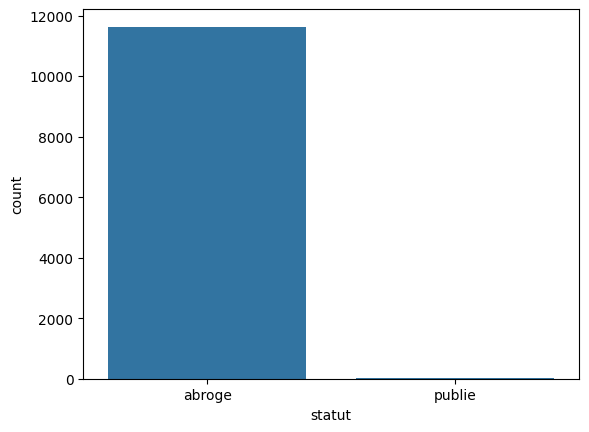

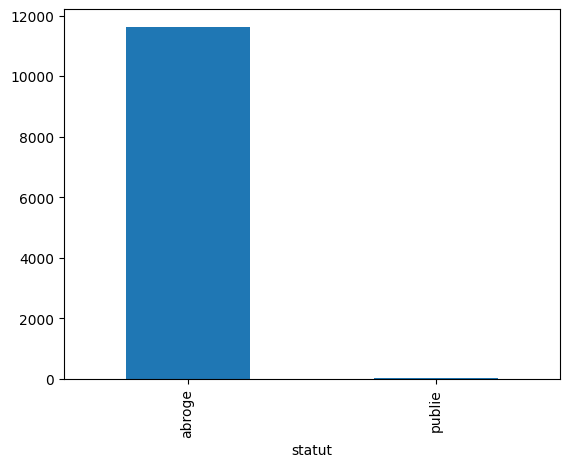

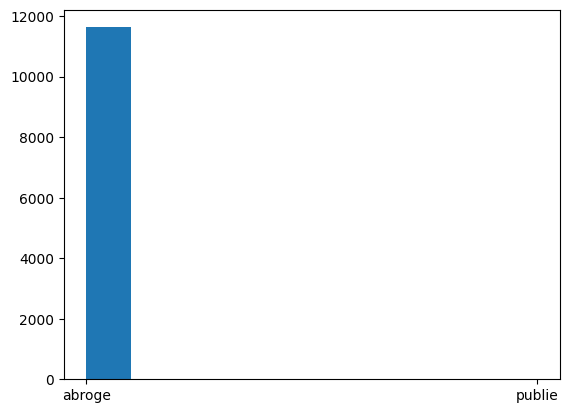

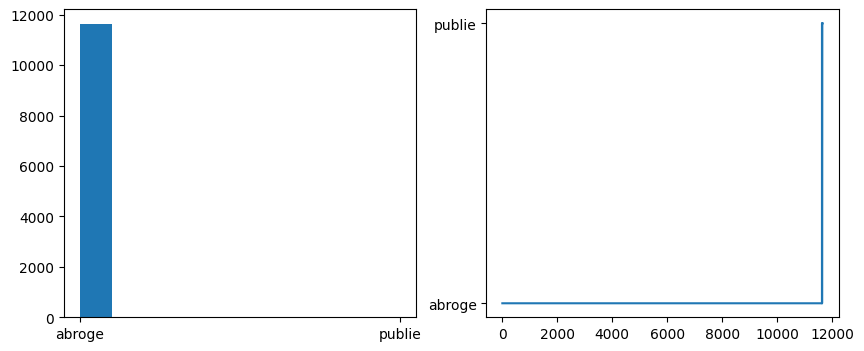

In [16]:
# Compter les occurrences d'une colonne categorielle
import seaborn as sns
sns.countplot(x="statut", data=df)
plt.show()

# Equivalent en pandas pur
df["statut"].value_counts().plot(kind="bar")
plt.show()

# Histogramme d'une variable numerique
plt.hist(df["statut"])
plt.show()

# Grille de subplots (si c'est vraiment ce que tu voulais)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df["statut"])
axes[1].plot(df["statut"])
plt.show()


In [23]:
df['statut'].value_counts()

statut
abroge    11631
publie       19
Name: count, dtype: int64

In [29]:
df["date_debut"] = pd.to_datetime(df["date_debut"], errors="coerce")
df["date_fin"]   = pd.to_datetime(df["date_fin"],   errors="coerce")

target = pd.Timestamp("2022-07-15")
active = df[(df["date_debut"] <= target) & (df["date_fin"] >= target)]


print(f'target')
print('active')

df["date_debut"].isna().sum(), df["date_fin"].isna().sum()

target
active


(np.int64(0), np.int64(4))

In [ ]:
"""
Test H_local sur n'importe quelle liste de villes.
Charge ERA5 et Aqueduct UNE SEULE FOIS, puis evalue chaque ville.
"""

import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path

# === Configuration (reutilise les chemins du notebook v4) ===
BASE = Path("../water_model/data")
RAW  = BASE / "raw"
AQUEDUCT_BWS = RAW / "aqueduct" / "bws_raw.tif"
AQUEDUCT_GWS = RAW / "aqueduct" / "gws_raw.tif"
ERA5_FULL    = RAW / "era5"     / "era5_monthly_1981_2022.nc"

W_AHP_3 = {"bws": 0.532/0.902, "aridity": 0.185/0.902, "gws": 0.185/0.902}
BWS_MAX_FR, GWS_MAX_FR = 0.60, 0.15


def evaluate_sites(sites_dict, years=[2022], month=7, verbose=True):
    """
    Calcule H_local pour une liste de sites.

    Parameters
    ----------
    sites_dict : dict {nom: (lat, lon)}
        Liste des sites a evaluer.
    years : list of int
        Annees a tester.
    month : int
        Mois (par defaut juillet, periode critique).
    verbose : bool
        Afficher la progression.

    Returns
    -------
    pd.DataFrame trie par H_local decroissant.
    """
    ds = xr.open_dataset(ERA5_FULL)
    td = "valid_time" if "valid_time" in ds.dims else "time"

    rows = []
    for i, (name, (lat, lon)) in enumerate(sites_dict.items()):
        if verbose and i % 10 == 0:
            print(f"  Traite {i}/{len(sites_dict)} : {name}")

        try:
            # Indicateurs structurels
            bws_raw = extract_raster_point(AQUEDUCT_BWS, lat, lon)
            gws_raw = extract_raster_point(AQUEDUCT_GWS, lat, lon)
            x_bws = float(np.clip(bws_raw / BWS_MAX_FR, 0, 1)) if not np.isnan(bws_raw) else np.nan
            x_gws = float(np.clip(gws_raw / GWS_MAX_FR, 0, 1)) if not np.isnan(gws_raw) else np.nan

            # ERA5
            pet_lat, pet_lon = find_land_gridpoint(lat, lon, ds)
            tp = ds["tp"].sel(latitude=lat, longitude=lon, method="nearest")
            t = pd.DatetimeIndex(tp[td].values)
            dy = t.days_in_month.values.astype(float)
            P = np.maximum(tp.values.astype(float) * dy * 1000, 0)
            pv = ds["pev"].sel(latitude=pet_lat, longitude=pet_lon, method="nearest")
            PET = np.maximum(-pv.values.astype(float) * dy * 1000, 0)

            x_a, ai = compute_aridity(P, PET, t)
            spei12 = compute_spei(P, PET, t, 12)
            spei3  = compute_spei(P, PET, t, 3)

            for year in years:
                idx = next((i for i, tt in enumerate(t)
                            if tt.year == year and tt.month == month), None)
                if idx is None:
                    continue
                d3, d12 = f_asym(spei3[idx]), f_asym(spei12[idx])
                s_struct = s_struct_arith(x_bws, x_a, x_gws, weights=W_AHP_3)
                s_conj   = s_conj_boltzmann(d3, d12)
                H, beta_t = assemble_H(s_struct, s_conj)

                # Categorie de severite
                if H < 0.33:
                    cat = "Faible"
                elif H < 0.55:
                    cat = "Modere"
                elif H < 0.75:
                    cat = "Eleve"
                else:
                    cat = "Critique"

                rows.append({
                    "Site": name, "Year": year,
                    "Lat": lat, "Lon": lon,
                    "x_BWS": round(x_bws, 3),
                    "x_Aridity": round(x_a, 3),
                    "x_GWS": round(x_gws, 3),
                    "AI": round(ai, 2),
                    "SPEI12": round(spei12[idx], 2),
                    "S_struct": round(s_struct, 3),
                    "S_conj": round(s_conj, 3),
                    "H_local": round(H, 3),
                    "Categorie": cat,
                })
        except Exception as e:
            print(f"  ERREUR sur {name} : {e}")

    ds.close()
    df3 = pd.DataFrame(rows).sort_values("H_local", ascending=False).reset_index(drop=True)
    return df


In [ ]:
df